In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data_pack/raw/turbine_telemetry_90day.csv")
df.head(10)

,timestamp,turbine_id,wind_speed,power_kw,availability
0,2026-03-01 00:00:00,T01,7.11,198.3,1.0
1,2026-03-01 00:00:00,T02,5.42,25.6,1.0
2,2026-03-01 00:00:00,T03,8.31,393.2,1.0
3,2026-03-01 00:00:00,T04,4.82,11.3,1.0
4,2026-03-01 00:00:00,T05,4.24,27.3,1.0
5,2026-03-01 01:00:00,T01,5.01,0.0,1.0
6,2026-03-01 01:00:00,T02,6.23,69.1,1.0
7,2026-03-01 01:00:00,T03,5.41,41.0,1.0
8,2026-03-01 01:00:00,T04,4.46,0.0,1.0
9,2026-03-01 01:00:00,T05,8.12,410.7,1.0


In [3]:
# Although the data is already ordered, ensure chronological order before time-series operations

df = df.sort_values(["timestamp", "turbine_id"]).reset_index(drop=True)

In [4]:
df.shape

(10725, 5)

It actually should be 10800 (90 * 24 * 5) but its 10725 so 75 rows are missing

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10725 entries, 0 to 10724
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     10725 non-null  str    
 1   turbine_id    10725 non-null  str    
 2   wind_speed    10725 non-null  float64
 3   power_kw      10725 non-null  float64
 4   availability  10725 non-null  float64
dtypes: float64(3), str(2)
memory usage: 419.1 KB


In [6]:
# Type casting required for timestamp column str -> datetime

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10725 entries, 0 to 10724
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     10725 non-null  datetime64[us]
 1   turbine_id    10725 non-null  str           
 2   wind_speed    10725 non-null  float64       
 3   power_kw      10725 non-null  float64       
 4   availability  10725 non-null  float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 419.1 KB


In [8]:
df.describe()

,timestamp,wind_speed,power_kw,availability
count,10725,10725.000000,10725.000000,10725.0
mean,2026-04-14 22:36:30.209790,7.542827,391.368904,1.0
min,2026-03-01 00:00:00,0.000000,0.000000,1.0
25%,2026-03-23 08:00:00,5.820000,60.200000,1.0
50%,2026-04-14 16:00:00,7.370000,220.200000,1.0
75%,2026-05-07 15:00:00,8.940000,545.300000,1.0
max,2026-05-29 23:00:00,32.190000,2000.000000,1.0
std,NaN,2.810325,462.693666,0.0


# Data Quality Checks

In [9]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
timestamp       0
turbine_id      0
wind_speed      0
power_kw        0
availability    0
dtype: int64


In [10]:
print("\nDuplicate rows:")
print(df.duplicated().sum())


Duplicate rows:
0


In [11]:
print("\nUnique turbines:")
print(df["turbine_id"].unique())


Unique turbines:
<StringArray>
['T01', 'T02', 'T03', 'T04', 'T05']
Length: 5, dtype: str


In [12]:
print("\nAvailability:")
print(df["availability"].value_counts(dropna=False))


Availability:
availability
1.0    10725
Name: count, dtype: int64


In [13]:
print("\nTime range:")
print(df["timestamp"].min())
print(df["timestamp"].max())


Time range:
2026-03-01 00:00:00
2026-05-29 23:00:00


The dataset contains no missing values or duplicate rows, includes all 5 expected turbines (T01–T05), and has availability = 1 for all 10,725 records. The timestamps span March 1 to May 29, 2026, indicating that the available telemetry covers the expected 90-day period, although the row count suggests some hourly turbine records are missing.

## Finding what the missing rows are

In [14]:
# Expected hourly timestamps
expected_hours = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="h"
)

print("Expected hourly timestamps:", len(expected_hours))

# Expected turbine-timestamp combinations
expected_combinations = len(expected_hours) * df["turbine_id"].nunique()

print("Expected timestamp-turbine combinations:", expected_combinations)
print("Actual rows:", len(df))
print("Missing combinations:", expected_combinations - len(df))

Expected hourly timestamps: 2160
Expected timestamp-turbine combinations: 10800
Actual rows: 10725
Missing combinations: 75


In [15]:
expected_grid = pd.MultiIndex.from_product(
    [
        expected_hours,
        sorted(df["turbine_id"].unique())
    ],
    names=["timestamp", "turbine_id"]
)

actual_grid = pd.MultiIndex.from_frame(
    df[["timestamp", "turbine_id"]]
)

missing_combinations = expected_grid.difference(actual_grid)

missing_df = missing_combinations.to_frame(index=False)

print("Number of missing combinations:", len(missing_df))

missing_df.head(20)

Number of missing combinations: 75


,timestamp,turbine_id
0,2026-04-20 00:00:00,T01
1,2026-04-20 00:00:00,T02
2,2026-04-20 00:00:00,T03
3,2026-04-20 00:00:00,T04
4,2026-04-20 00:00:00,T05
5,2026-04-20 01:00:00,T01
6,2026-04-20 01:00:00,T02
7,2026-04-20 01:00:00,T03
8,2026-04-20 01:00:00,T04
9,2026-04-20 01:00:00,T05


In [16]:
missing_by_date = (
    missing_df
    .assign(date=missing_df["timestamp"].dt.date)
    .groupby("date")
    .size()
    .sort_values(ascending=False)
)

print(missing_by_date)

date
2026-04-20    75
dtype: int64


In [17]:
missing_by_turbine = (
    missing_df["turbine_id"]
    .value_counts()
    .sort_index()
)

print(missing_by_turbine)

turbine_id
T01    15
T02    15
T03    15
T04    15
T05    15
Name: count, dtype: int64


In [18]:
print(
    missing_df
    .sort_values("timestamp")
    .head(10)
)

            timestamp turbine_id
0 2026-04-20 00:00:00        T01
1 2026-04-20 00:00:00        T02
2 2026-04-20 00:00:00        T03
3 2026-04-20 00:00:00        T04
4 2026-04-20 00:00:00        T05
9 2026-04-20 01:00:00        T05
7 2026-04-20 01:00:00        T03
8 2026-04-20 01:00:00        T04
5 2026-04-20 01:00:00        T01
6 2026-04-20 01:00:00        T02


In [19]:
missing_timestamps = (
    missing_df["timestamp"]
    .drop_duplicates()
    .sort_values()
)

timestamp_gaps = missing_timestamps.diff()

print(
    timestamp_gaps.value_counts().head(20)
)

timestamp
0 days 01:00:00    14
Name: count, dtype: int64


In [20]:
missing_df = missing_df.sort_values(
    ["timestamp", "turbine_id"]
).reset_index(drop=True)

missing_df["time_diff"] = (
    missing_df["timestamp"].diff()
)

missing_df.head(20)

,timestamp,turbine_id,time_diff
0,2026-04-20 00:00:00,T01,NaT
1,2026-04-20 00:00:00,T02,0 days 00:00:00
2,2026-04-20 00:00:00,T03,0 days 00:00:00
3,2026-04-20 00:00:00,T04,0 days 00:00:00
4,2026-04-20 00:00:00,T05,0 days 00:00:00
5,2026-04-20 01:00:00,T01,0 days 01:00:00
6,2026-04-20 01:00:00,T02,0 days 00:00:00
7,2026-04-20 01:00:00,T03,0 days 00:00:00
8,2026-04-20 01:00:00,T04,0 days 00:00:00
9,2026-04-20 01:00:00,T05,0 days 00:00:00


The data on 20th April is missing for 15 hrs

# Univariate EDA

In [21]:
numeric_cols = [
    "wind_speed",
    "power_kw",
    "availability"
]

df[numeric_cols].describe()

,wind_speed,power_kw,availability
count,10725.000000,10725.000000,10725.0
mean,7.542827,391.368904,1.0
std,2.810325,462.693666,0.0
min,0.000000,0.000000,1.0
25%,5.820000,60.200000,1.0
50%,7.370000,220.200000,1.0
75%,8.940000,545.300000,1.0
max,32.190000,2000.000000,1.0


In [22]:
df.groupby("turbine_id")[numeric_cols].describe()

wind_speed                                                     \
                count      mean       std   min   25%   50%   75%    max   
turbine_id                                                                 
T01            2145.0  7.269389  2.269786  0.00  5.74  7.29  8.77  14.30   
T02            2145.0  7.354345  2.316409  0.00  5.80  7.33  8.93  15.20   
T03            2145.0  7.357534  2.222082  0.68  5.81  7.29  8.82  14.97   
T04            2145.0  7.274252  2.242192  0.00  5.77  7.33  8.74  15.31   
T05            2145.0  8.458615  4.238594  0.02  6.06  7.61  9.54  32.19   

           power_kw              ...                availability            \
              count        mean  ...    75%     max        count mean  std   
turbine_id                       ...                                         
T01          2145.0  386.142051  ...  540.6  2000.0       2145.0  1.0  0.0   
T02          2145.0  403.732168  ...  568.8  2000.0       2145.0  1.0  0.0   
T03          2145.0  389.207040  ...  535.2  2000.0       2145.0  1.0  0.0   
T04          2145.0  379.803450  ...  515.6  2000.0       2145.0  1.0  0.0   
T05          2145.0  397.959814  ...  557.1  2000.0       2145.0  1.0  0.0   

                                     
            min  25%  50%  75%  max  
turbine_id                           
T01         1.0  1.0  1.0  1.0  1.0  
T02         1.0  1.0  1.0  1.0  1.0  
T03         1.0  1.0  1.0  1.0  1.0  
T04         1.0  1.0  1.0  1.0  1.0  
T05         1.0  1.0  1.0  1.0  1.0  

[5 rows x 24 columns]

In [23]:
turbine_summary = df.groupby("turbine_id").agg(
    wind_mean=("wind_speed", "mean"),
    wind_median=("wind_speed", "median"),
    wind_min=("wind_speed", "min"),
    wind_max=("wind_speed", "max"),
    
    power_mean=("power_kw", "mean"),
    power_median=("power_kw", "median"),
    power_min=("power_kw", "min"),
    power_max=("power_kw", "max"),
    
    availability_mean=("availability", "mean")
)

turbine_summary

,wind_mean,wind_median,wind_min,wind_max,power_mean,power_median,power_min,power_max,availability_mean
turbine_id,,,,,,,,,
T01,7.269389,7.29,0.00,14.30,386.142051,212.6,0.0,2000.0,1.0
T02,7.354345,7.33,0.00,15.20,403.732168,223.1,0.0,2000.0,1.0
T03,7.357534,7.29,0.68,14.97,389.207040,213.4,0.0,2000.0,1.0
T04,7.274252,7.33,0.00,15.31,379.803450,221.7,0.0,2000.0,1.0
T05,8.458615,7.61,0.02,32.19,397.959814,225.5,0.0,2000.0,1.0


## Wind Speed Distributions

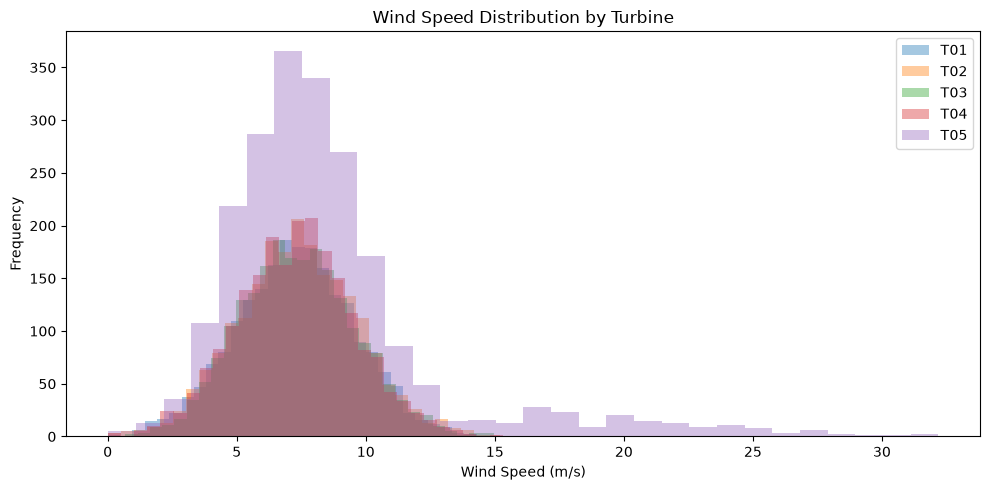

In [24]:
plt.figure(figsize=(10, 5))

for turbine in sorted(df["turbine_id"].unique()):
    temp = df[df["turbine_id"] == turbine]
    
    plt.hist(
        temp["wind_speed"],
        bins=30,
        alpha=0.4,
        label=turbine
    )

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.title("Wind Speed Distribution by Turbine")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

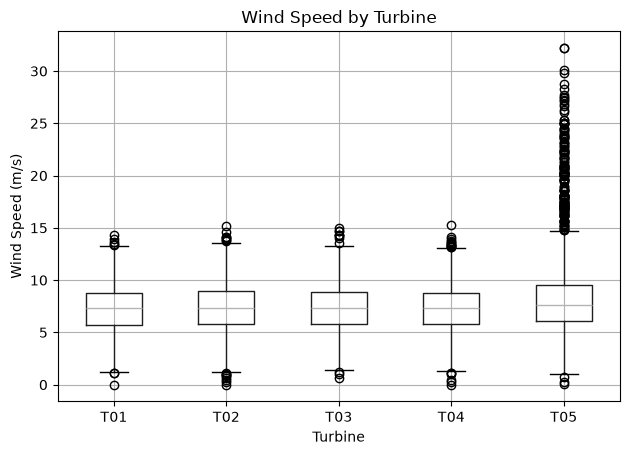

In [25]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="wind_speed",
    by="turbine_id"
)

plt.title("Wind Speed by Turbine")
plt.suptitle("")
plt.xlabel("Turbine")
plt.ylabel("Wind Speed (m/s)")
plt.tight_layout()
plt.show()

## Power Distributions

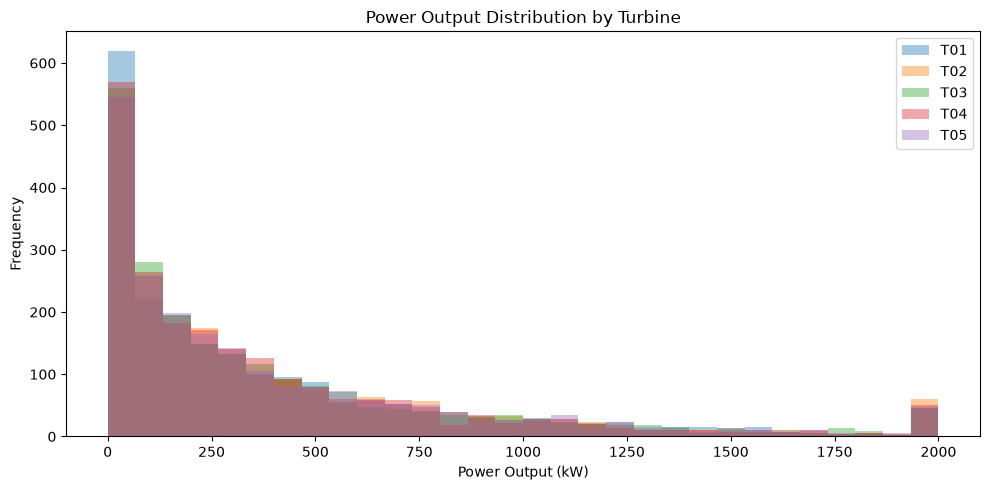

In [26]:
plt.figure(figsize=(10, 5))

for turbine in sorted(df["turbine_id"].unique()):
    temp = df[df["turbine_id"] == turbine]
    
    plt.hist(
        temp["power_kw"],
        bins=30,
        alpha=0.4,
        label=turbine
    )

plt.xlabel("Power Output (kW)")
plt.ylabel("Frequency")
plt.title("Power Output Distribution by Turbine")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

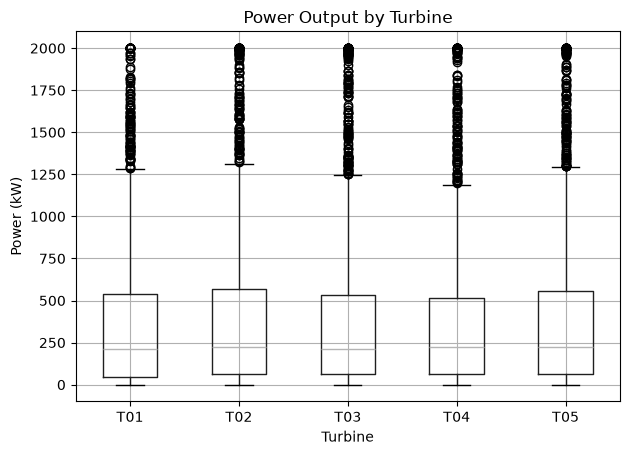

In [27]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="power_kw",
    by="turbine_id"
)

plt.title("Power Output by Turbine")
plt.suptitle("")
plt.xlabel("Turbine")
plt.ylabel("Power (kW)")
plt.tight_layout()
plt.show()

Univariate EDA identified T05 as a candidate for further investigation because its wind-speed distribution differs substantially from the other turbines, with a higher mean and an unusually long upper tail. This suggests that the reported wind-speed measurements for T05 may contain an abnormal period or measurement issue. However, the cause cannot be determined from the univariate analysis alone.

# Physical Relationships

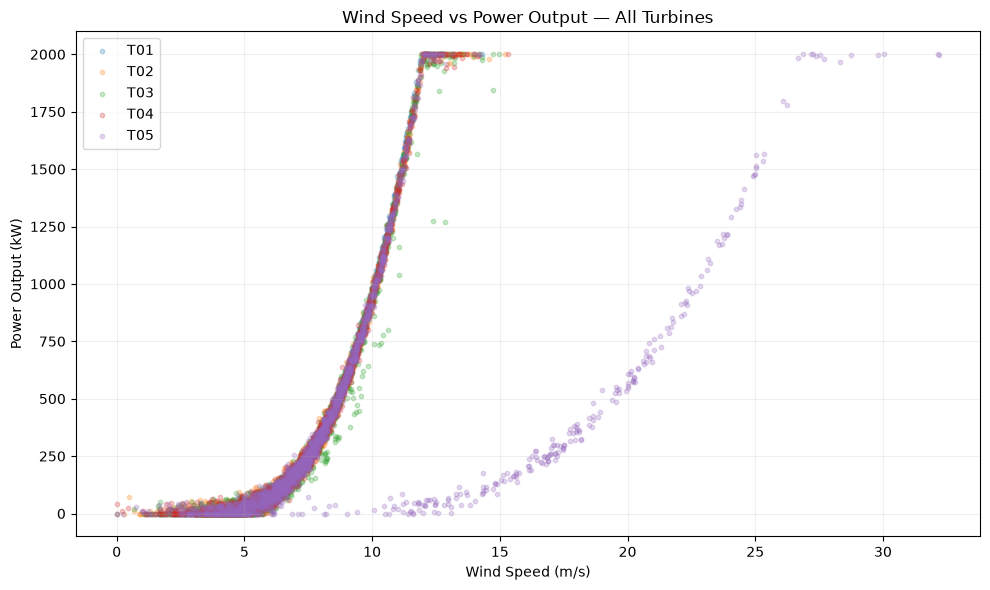

In [28]:
plt.figure(figsize=(10, 6))

for turbine in sorted(df["turbine_id"].unique()):
    temp = df[df["turbine_id"] == turbine]

    plt.scatter(
        temp["wind_speed"],
        temp["power_kw"],
        alpha=0.25,
        s=10,
        label=turbine
    )

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power Output (kW)")
plt.title("Wind Speed vs Power Output — All Turbines")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

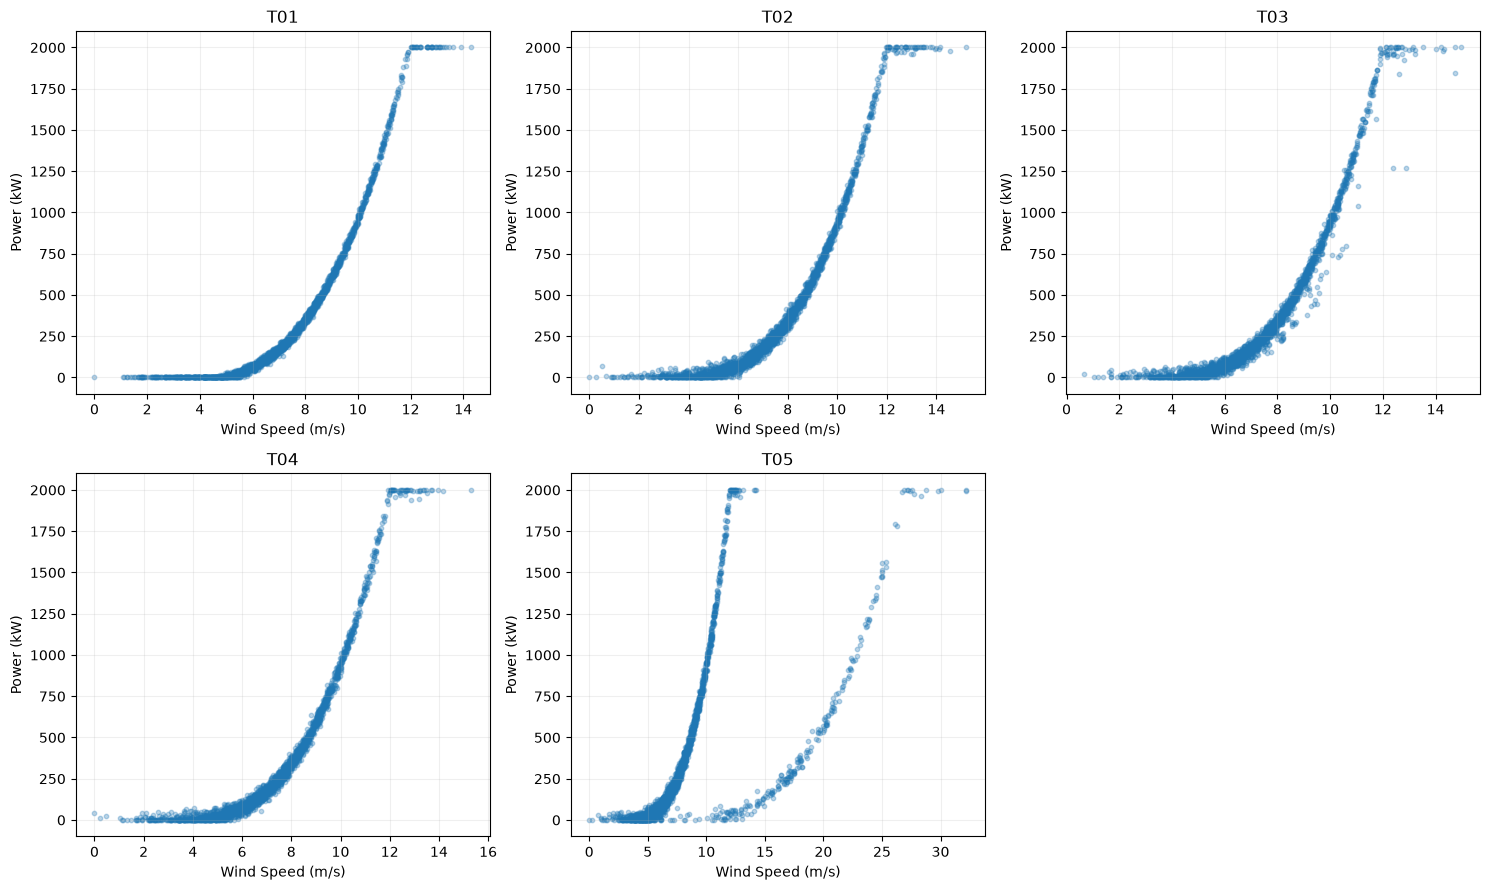

In [29]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, turbine in enumerate(sorted(df["turbine_id"].unique())):

    temp = df[df["turbine_id"] == turbine]

    axes[i].scatter(
        temp["wind_speed"],
        temp["power_kw"],
        alpha=0.3,
        s=10
    )

    axes[i].set_title(turbine)
    axes[i].set_xlabel("Wind Speed (m/s)")
    axes[i].set_ylabel("Power (kW)")
    axes[i].grid(alpha=0.2)

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

The wind-speed/power relationship reveals a clear anomaly in one turbine. Unlike the other turbines, which broadly follow a common power curve, this turbine exhibits a second power curve shifted toward substantially higher wind-speed values. This indicates that the reported wind-speed measurements are inconsistent with the normal physical relationship and warrants temporal investigation to determine when the deviation occurs and whether it represents a scaling, unit, or sensor issue.

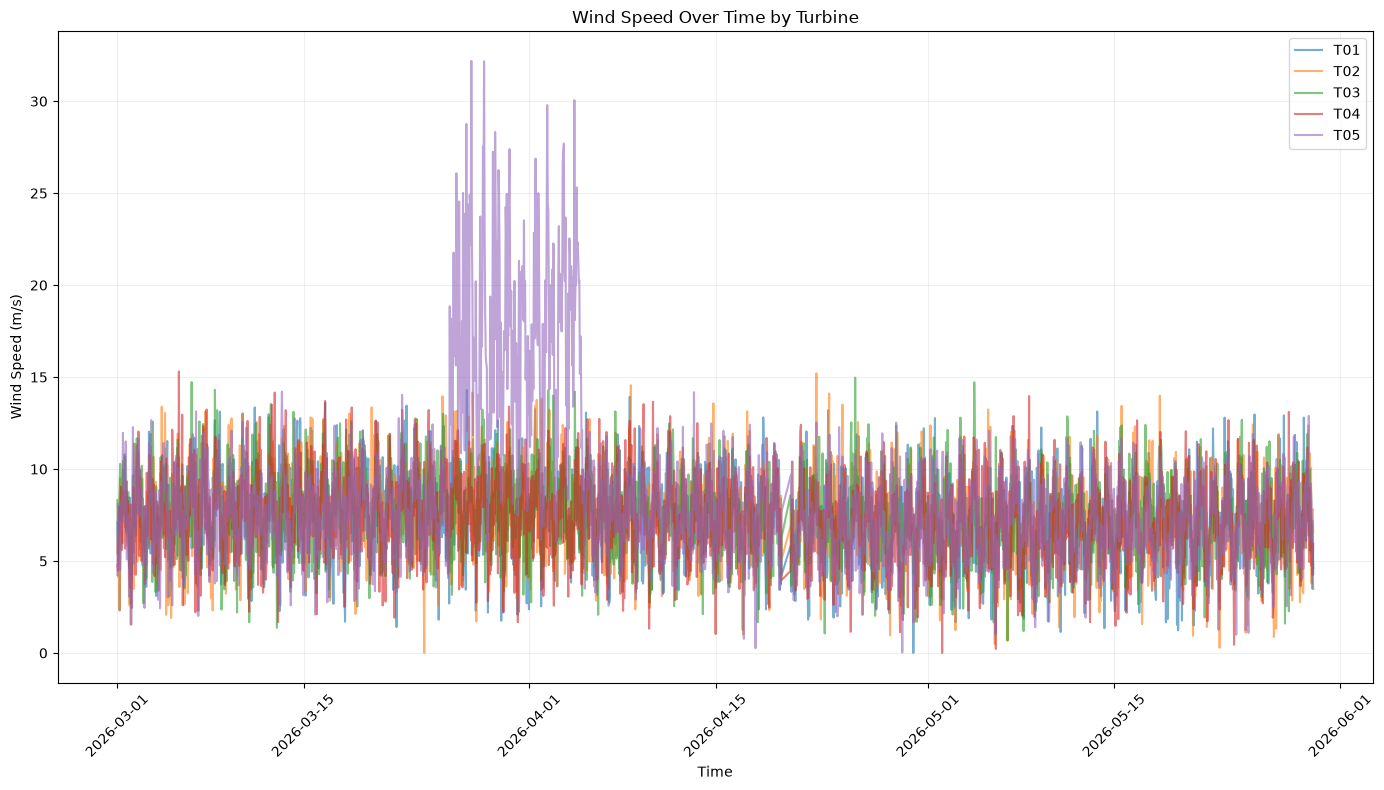

In [30]:
plt.figure(figsize=(14, 8))

for turbine in sorted(df["turbine_id"].unique()):
    temp = df[df["turbine_id"] == turbine]

    plt.plot(
        temp["timestamp"],
        temp["wind_speed"],
        label=turbine,
        alpha=0.6
    )

plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")
plt.title("Wind Speed Over Time by Turbine")
plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

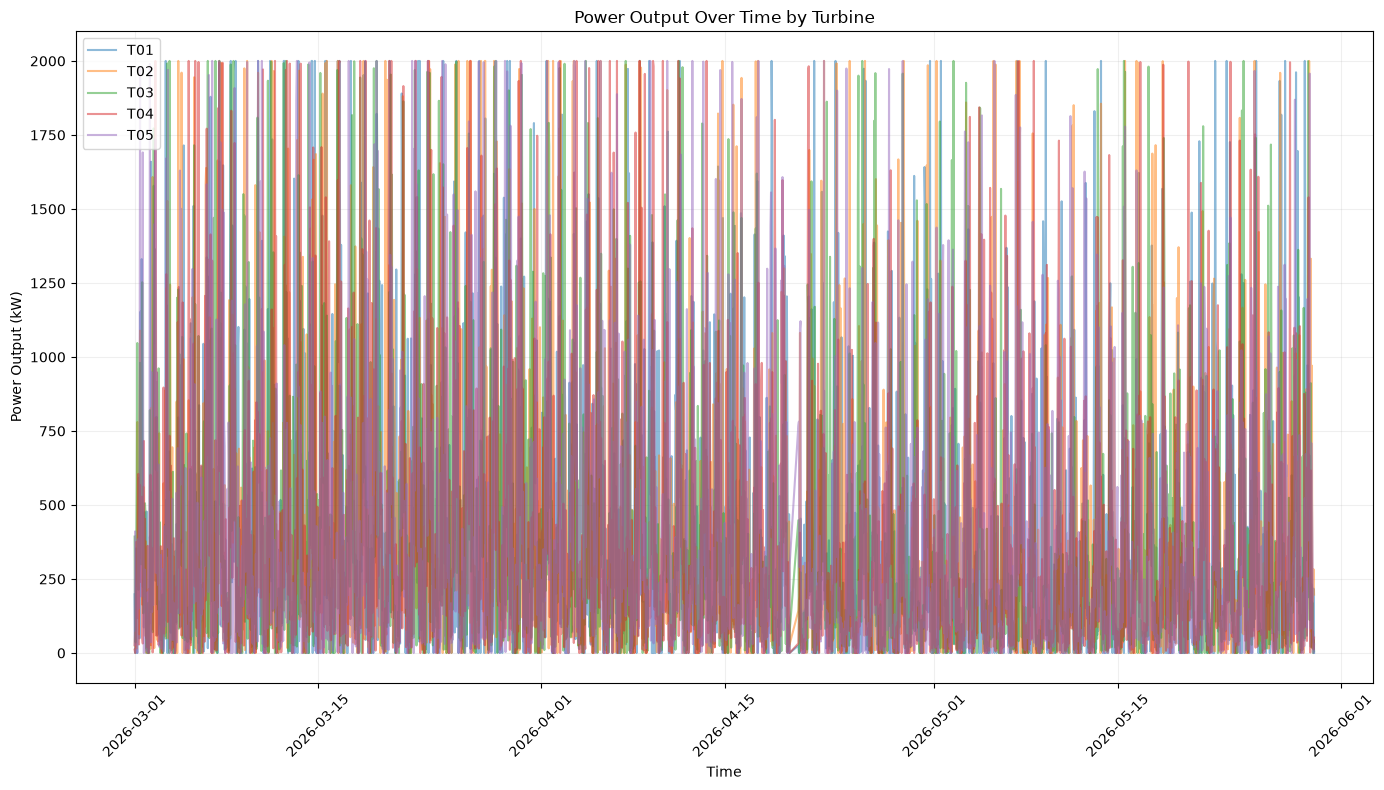

In [31]:
plt.figure(figsize=(14, 8))

for turbine in sorted(df["turbine_id"].unique()):
    temp = df[df["turbine_id"] == turbine]

    plt.plot(
        temp["timestamp"],
        temp["power_kw"],
        label=turbine,
        alpha=0.5
    )

plt.xlabel("Time")
plt.ylabel("Power Output (kW)")
plt.title("Power Output Over Time by Turbine")
plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

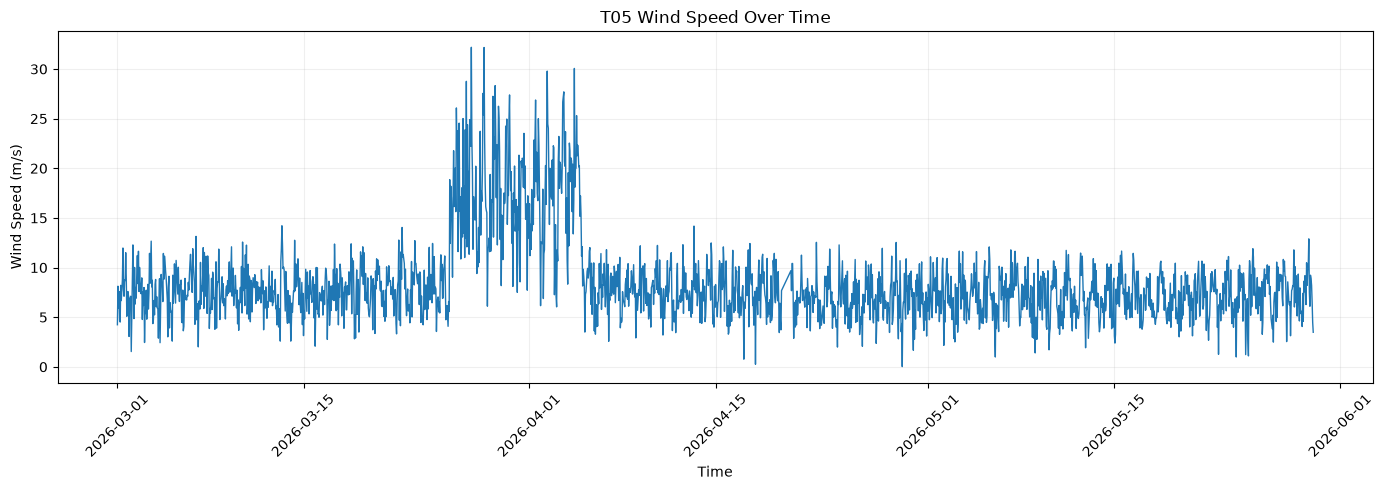

In [32]:
t05 = df[df["turbine_id"] == "T05"].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    t05["timestamp"],
    t05["wind_speed"],
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")
plt.title("T05 Wind Speed Over Time")
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Temporal investigation shows that the abnormal wind-speed behavior identified for one turbine is localized to a specific period around late March to early April. Outside this period, the turbine's wind-speed measurements return to a range comparable with the other turbines. The temporary nature of the deviation suggests a data-quality or sensor-related issue rather than a persistent physical difference between turbines.

In [33]:
before = df[
    (df["timestamp"] >= "2026-03-15") &
    (df["timestamp"] < "2026-03-26")
]

during = df[
    (df["timestamp"] >= "2026-03-26") &
    (df["timestamp"] <= "2026-04-04 23:00:00")
]

after = df[
    (df["timestamp"] > "2026-04-04 23:00:00") &
    (df["timestamp"] <= "2026-04-15")
]

In [34]:
def wind_summary(data, period_name):
    result = (
        data.groupby("turbine_id")["wind_speed"]
        .agg(["mean", "median", "std", "min", "max"])
    )
    
    result["period"] = period_name
    
    return result.reset_index()


comparison = pd.concat([
    wind_summary(before, "Before"),
    wind_summary(during, "During"),
    wind_summary(after, "After")
])

comparison

,turbine_id,mean,median,std,min,max,period
0,T01,7.690606,7.715,2.300732,1.41,13.61,Before
1,T02,7.842803,7.805,2.197128,0.00,13.96,Before
2,T03,7.920758,7.950,2.165132,2.98,13.00,Before
3,T04,7.755909,7.740,2.287299,1.92,13.70,Before
4,T05,7.655909,7.710,2.166070,2.08,14.04,Before
0,T01,7.718208,7.825,2.322999,1.75,14.30,During
1,T02,7.833750,7.745,2.366345,1.71,14.16,During
2,T03,7.869667,7.790,2.175390,2.75,14.29,During
3,T04,7.630417,7.860,2.262115,1.67,13.40,During
4,T05,17.618125,17.315,5.273933,6.04,32.19,During


In [35]:
comparison_pivot = (
    comparison
    .pivot(
        index="turbine_id",
        columns="period",
        values="mean"
    )
)

comparison_pivot

period,After,Before,During
turbine_id,,,
T01,7.600913,7.690606,7.718208
T02,7.436390,7.842803,7.833750
T03,7.411950,7.920758,7.869667
T04,7.424481,7.755909,7.630417
T05,7.692490,7.655909,17.618125


In [36]:
for period_name, data in [
    ("Before", before),
    ("During", during),
    ("After", after)
]:
    
    print(f"\n{period_name}")
    
    for turbine in sorted(data["turbine_id"].unique()):
        
        temp = data[data["turbine_id"] == turbine]
        
        pearson = temp["wind_speed"].corr(
            temp["power_kw"],
            method="pearson"
        )
        
        spearman = temp["wind_speed"].corr(
            temp["power_kw"],
            method="spearman"
        )
        
        print(
            turbine,
            f"Pearson={pearson:.3f}",
            f"Spearman={spearman:.3f}"
        )


Before
T01 Pearson=0.895 Spearman=0.998
T02 Pearson=0.910 Spearman=0.995
T03 Pearson=0.920 Spearman=0.994
T04 Pearson=0.910 Spearman=0.991
T05 Pearson=0.907 Spearman=0.991

During
T01 Pearson=0.908 Spearman=0.996
T02 Pearson=0.926 Spearman=0.992
T03 Pearson=0.925 Spearman=0.994
T04 Pearson=0.888 Spearman=0.994
T05 Pearson=0.919 Spearman=0.991

After
T01 Pearson=0.907 Spearman=0.997
T02 Pearson=0.902 Spearman=0.992
T03 Pearson=0.884 Spearman=0.991
T04 Pearson=0.891 Spearman=0.992
T05 Pearson=0.905 Spearman=0.993


The anomaly is likely a scaling/unit inconsistency in T05's wind-speed measurements rather than a power-output sensor problem.

In [37]:
# Create a reference wind speed from the unaffected turbines
reference = (
    df[df["turbine_id"] != "T05"]
    .groupby("timestamp")["wind_speed"]
    .median()
    .rename("reference_wind_speed")
)

# Get T05 observations during the detected anomaly
t05_during = (
    df[
        (df["turbine_id"] == "T05") &
        (df["timestamp"] >= "2026-03-26") &
        (df["timestamp"] <= "2026-04-04 23:00:00")
    ]
    .set_index("timestamp")
    .join(reference)
)

# Calculate ratio
t05_during["wind_ratio"] = (
    t05_during["wind_speed"] /
    t05_during["reference_wind_speed"]
)

t05_during["wind_ratio"].describe()

count    240.000000
mean       2.318780
std        0.692768
min        0.720468
25%        1.867778
50%        2.239306
75%        2.652330
max        5.149508
Name: wind_ratio, dtype: float64

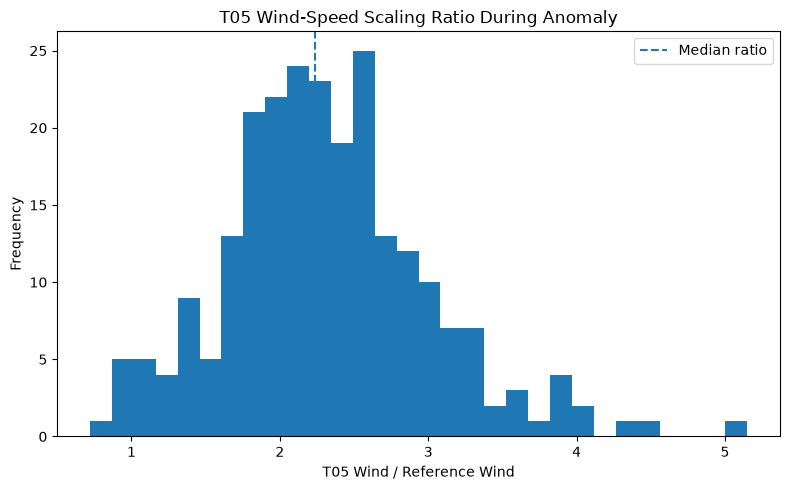

Median scaling ratio: 2.239306387561419


In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    t05_during["wind_ratio"],
    bins=30
)

plt.axvline(
    t05_during["wind_ratio"].median(),
    linestyle="--",
    label="Median ratio"
)

plt.xlabel("T05 Wind / Reference Wind")
plt.ylabel("Frequency")
plt.title("T05 Wind-Speed Scaling Ratio During Anomaly")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Median scaling ratio:",
    t05_during["wind_ratio"].median()
)

Sensor investigation: During the identified abnormal period, T05 wind-speed measurements were substantially higher than the contemporaneous median wind speed of the other turbines. The median ratio was approximately 2.24, indicating that the T05 measurements were subject to a multiplicative scaling effect. Because the ratio shows substantial variability, 2.24 is treated as an estimated scaling factor rather than an exact conversion factor. Further validation against the turbine power curve is required before applying any correction.

In [39]:
df_corrected = df.copy()

t05_anomaly = (
    (df_corrected["turbine_id"] == "T05") &
    (df_corrected["timestamp"] >= "2026-03-26") &
    (df_corrected["timestamp"] <= "2026-04-04 23:00:00")
)

scaling_factor = t05_during["wind_ratio"].median()

df_corrected.loc[t05_anomaly, "wind_speed_corrected"] = (
    df_corrected.loc[t05_anomaly, "wind_speed"]
    / scaling_factor
)

# For all other observations, keep original wind speed
df_corrected.loc[~t05_anomaly, "wind_speed_corrected"] = (
    df_corrected.loc[~t05_anomaly, "wind_speed"]
)

print("Estimated scaling factor:", scaling_factor)

Estimated scaling factor: 2.239306387561419


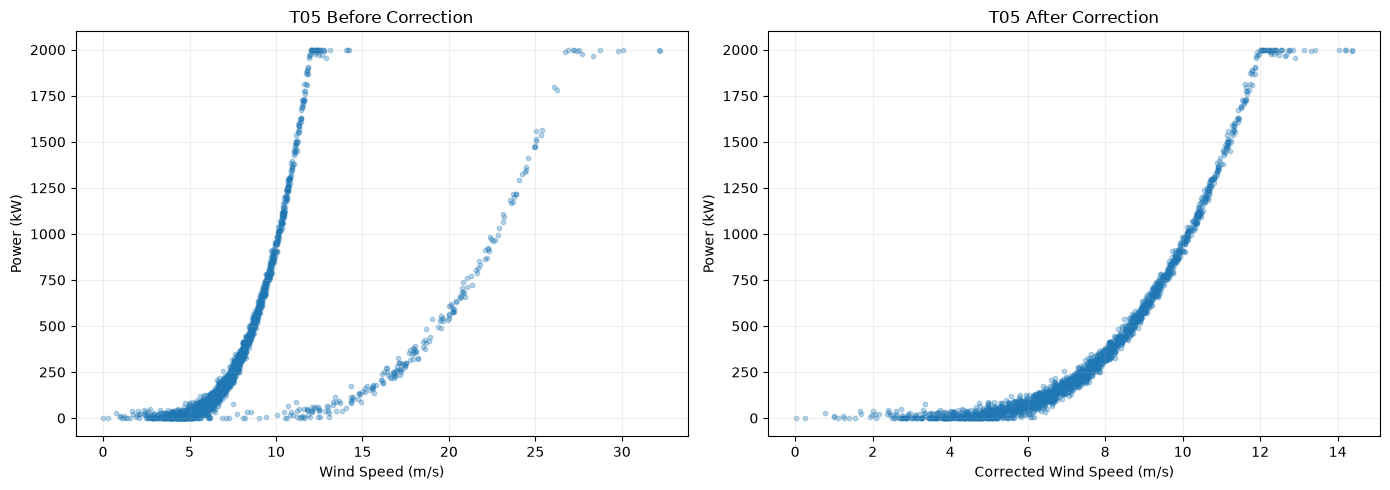

In [40]:
t05_original = df[
    df["turbine_id"] == "T05"
]

t05_corrected = df_corrected[
    df_corrected["turbine_id"] == "T05"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before correction
axes[0].scatter(
    t05_original["wind_speed"],
    t05_original["power_kw"],
    alpha=0.3,
    s=10
)

axes[0].set_title("T05 Before Correction")
axes[0].set_xlabel("Wind Speed (m/s)")
axes[0].set_ylabel("Power (kW)")
axes[0].grid(alpha=0.2)

# After correction
axes[1].scatter(
    t05_corrected["wind_speed_corrected"],
    t05_corrected["power_kw"],
    alpha=0.3,
    s=10
)

axes[1].set_title("T05 After Correction")
axes[1].set_xlabel("Corrected Wind Speed (m/s)")
axes[1].set_ylabel("Power (kW)")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Validation: Applying the estimated scaling factor to a copy of the T05 wind-speed measurements during the anomalous period substantially restored the expected wind-speed–power relationship. The previously separated power curve shifted back into alignment with the normal turbine power curve. This supports the hypothesis that the anomaly was caused by a temporary multiplicative scaling/unit inconsistency in the wind-speed measurements. The raw data was retained unchanged, and the correction was applied only to a derived feature.

In [41]:
analysis_df = df_corrected.copy()

In [42]:
def expected_power(wind_speed):
    if wind_speed < 3:
        return 0
    
    elif wind_speed < 12:
        return 2000 * ((wind_speed - 3) / 9) ** 3
    
    elif wind_speed <= 25:
        return 2000
    
    else:
        return 0

In [43]:
analysis_df["expected_power_kw"] = (
    analysis_df["wind_speed_corrected"]
    .apply(expected_power)
)

In [44]:
power_analysis = analysis_df[
    analysis_df["expected_power_kw"] > 200
].copy()

In [45]:
power_analysis["power_ratio"] = (
    power_analysis["power_kw"] /
    power_analysis["expected_power_kw"]
)

In [46]:
power_analysis["power_ratio"].describe()

count    5635.000000
mean        0.999589
std         0.067073
min         0.516534
25%         0.974897
50%         1.001722
75%         1.029985
max         1.288732
Name: power_ratio, dtype: float64

In [47]:
power_ratio_by_turbine = (
    power_analysis
    .groupby("turbine_id")["power_ratio"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

power_ratio_by_turbine

,count,mean,median,std,min,max
turbine_id,,,,,,
T01,1110,1.015731,1.017954,0.039716,0.825687,1.143664
T02,1137,1.002079,1.000000,0.064424,0.733216,1.280451
T03,1115,0.982721,0.998418,0.090552,0.516534,1.288732
T04,1129,0.997583,0.997810,0.062995,0.701226,1.278603
T05,1144,0.999873,0.998525,0.063805,0.747009,1.277356


<Figure size 900x500 with 0 Axes>

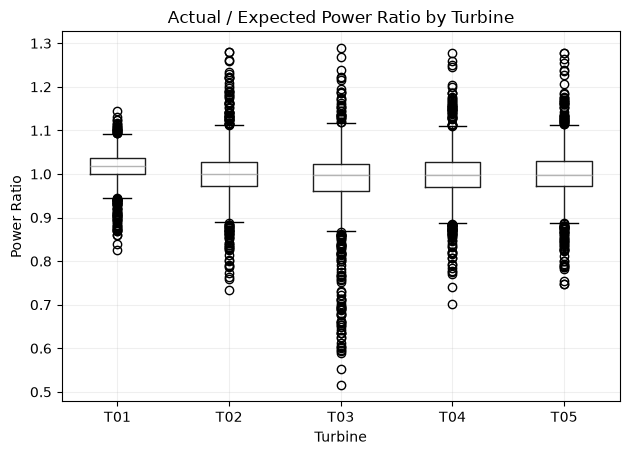

In [48]:
plt.figure(figsize=(9, 5))

power_analysis.boxplot(
    column="power_ratio",
    by="turbine_id"
)

plt.title("Actual / Expected Power Ratio by Turbine")
plt.suptitle("")
plt.xlabel("Turbine")
plt.ylabel("Power Ratio")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The actual-to-expected power analysis identifies T03 as a candidate anomaly. Compared with the other turbines, T03 has a substantially larger lower tail in the actual/expected power ratio, indicating periods where measured power is considerably lower than expected from the reported wind speed. This suggests a potential power-output or sensor-quality issue that requires temporal investigation.

In [49]:
power_analysis["date"] = (
    power_analysis["timestamp"].dt.date
)

daily_power_ratio = (
    power_analysis
    .groupby(["date", "turbine_id"])["power_ratio"]
    .median()
    .reset_index()
)

daily_power_ratio.head()

,date,turbine_id,power_ratio
0,2026-03-01,T01,1.016565
1,2026-03-01,T02,0.990275
2,2026-03-01,T03,0.996190
3,2026-03-01,T04,0.999741
4,2026-03-01,T05,0.989058


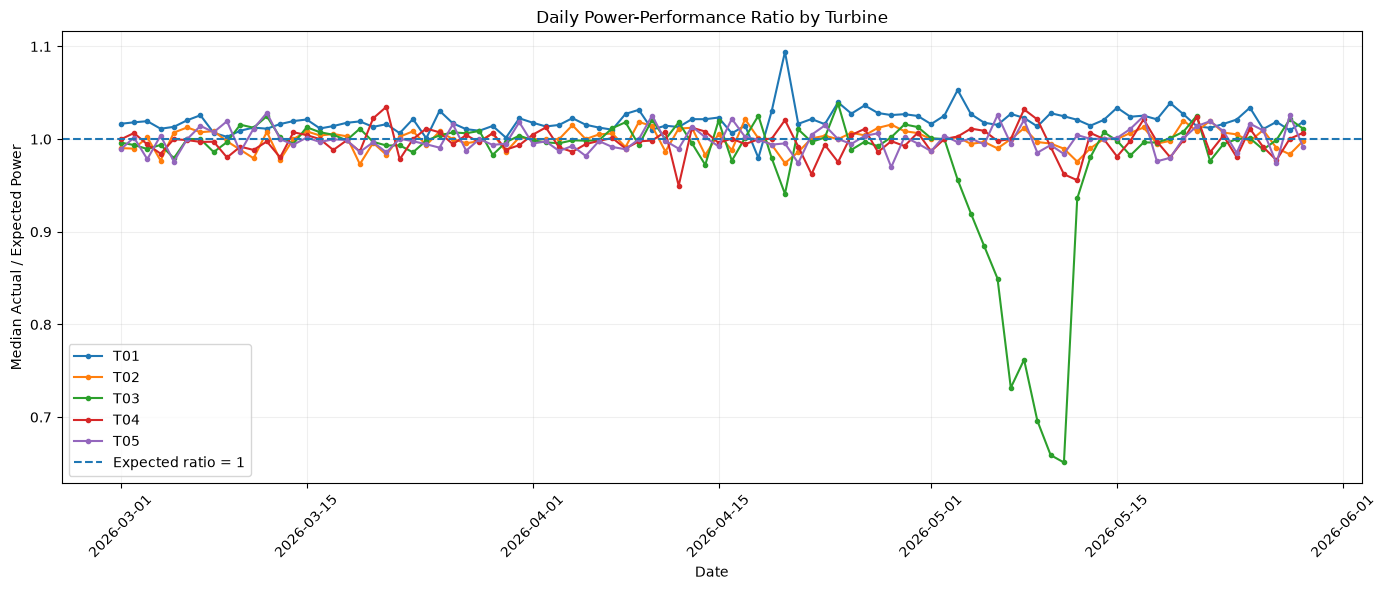

In [50]:
plt.figure(figsize=(14, 6))

for turbine in sorted(daily_power_ratio["turbine_id"].unique()):

    temp = daily_power_ratio[
        daily_power_ratio["turbine_id"] == turbine
    ]

    plt.plot(
        temp["date"],
        temp["power_ratio"],
        marker="o",
        markersize=3,
        label=turbine
    )

plt.axhline(
    1.0,
    linestyle="--",
    label="Expected ratio = 1"
)

plt.xlabel("Date")
plt.ylabel("Median Actual / Expected Power")
plt.title("Daily Power-Performance Ratio by Turbine")
plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
lowest_days = (
    daily_power_ratio
    .sort_values("power_ratio")
    .groupby("turbine_id")
    .head(10)
)

lowest_days.sort_values(
    ["turbine_id", "power_ratio"]
)

,date,turbine_id,power_ratio
240,2026-04-18,T01,0.979717
115,2026-03-24,T01,1.000895
145,2026-03-30,T01,1.001524
40,2026-03-09,T01,1.002462
230,2026-04-16,T01,1.006321
105,2026-03-22,T01,1.006437
35,2026-03-08,T01,1.006706
135,2026-03-28,T01,1.009079
45,2026-03-10,T01,1.009083
440,2026-05-28,T01,1.009491


In [52]:
before_power = power_analysis[
    (power_analysis["timestamp"] >= "2026-04-20") &
    (power_analysis["timestamp"] < "2026-05-04")
]

during_power = power_analysis[
    (power_analysis["timestamp"] >= "2026-05-04") &
    (power_analysis["timestamp"] < "2026-05-12")
]

after_power = power_analysis[
    (power_analysis["timestamp"] >= "2026-05-12") &
    (power_analysis["timestamp"] < "2026-05-20")
]

In [53]:
def performance_summary(data, period_name):

    result = (
        data.groupby("turbine_id")["power_ratio"]
        .agg(["mean", "median", "std", "min", "max"])
    )

    result["period"] = period_name

    return result.reset_index()


performance_comparison = pd.concat([
    performance_summary(before_power, "Before"),
    performance_summary(during_power, "During"),
    performance_summary(after_power, "After")
])

performance_comparison

,turbine_id,mean,median,std,min,max,period
0,T01,1.028149,1.026464,0.036656,0.907499,1.143664,Before
1,T02,1.007187,1.002396,0.071143,0.733216,1.280451,Before
2,T03,1.001854,1.000000,0.068530,0.781557,1.288732,Before
3,T04,0.993798,0.992099,0.066792,0.769689,1.204940,Before
4,T05,1.002879,0.997247,0.058594,0.800670,1.164979,Before
0,T01,1.027280,1.023722,0.036462,0.919634,1.129817,During
1,T02,0.992342,0.995812,0.058220,0.799438,1.142399,During
2,T03,0.766496,0.758643,0.116809,0.516534,1.018529,During
3,T04,1.010410,1.007376,0.069820,0.860514,1.184812,During
4,T05,0.996061,0.996546,0.056898,0.785751,1.167242,During


In [54]:
performance_pivot = (
    performance_comparison
    .pivot(
        index="turbine_id",
        columns="period",
        values="median"
    )
)

performance_pivot

period,After,Before,During
turbine_id,,,
T01,1.024922,1.026464,1.023722
T02,0.999520,1.002396,0.995812
T03,0.993976,1.000000,0.758643
T04,0.993550,0.992099,1.007376
T05,1.002733,0.997247,0.996546


In [55]:
# Candidate turbine identified from the previous analysis
candidate_turbine = (
    performance_comparison
    .groupby("turbine_id")["median"]
    .mean()
    .idxmin()
)

print("Candidate turbine:", candidate_turbine)

Candidate turbine: T03


In [56]:
candidate_data = analysis_df[
    analysis_df["turbine_id"] == candidate_turbine
].copy()

candidate_data["period"] = "Other"

candidate_data.loc[
    (candidate_data["timestamp"] >= "2026-05-04") &
    (candidate_data["timestamp"] < "2026-05-12"),
    "period"
] = "During"

candidate_data.groupby("period")[
    ["wind_speed_corrected", "power_kw", "expected_power_kw"]
].mean()

,wind_speed_corrected,power_kw,expected_power_kw
period,,,
During,6.771927,222.979167,284.467499
Other,7.415105,405.548950,405.103305


The temporal investigation identifies a temporary performance anomaly in T03 between May 4 and May 11. During this period, measured power was substantially below the power predicted from its reported wind speed, while the same performance ratio remained close to 1 before and after the period. This suggests a temporary power-output measurement or turbine-performance issue. Further investigation is required to distinguish sensor drift from an actual operational reduction.

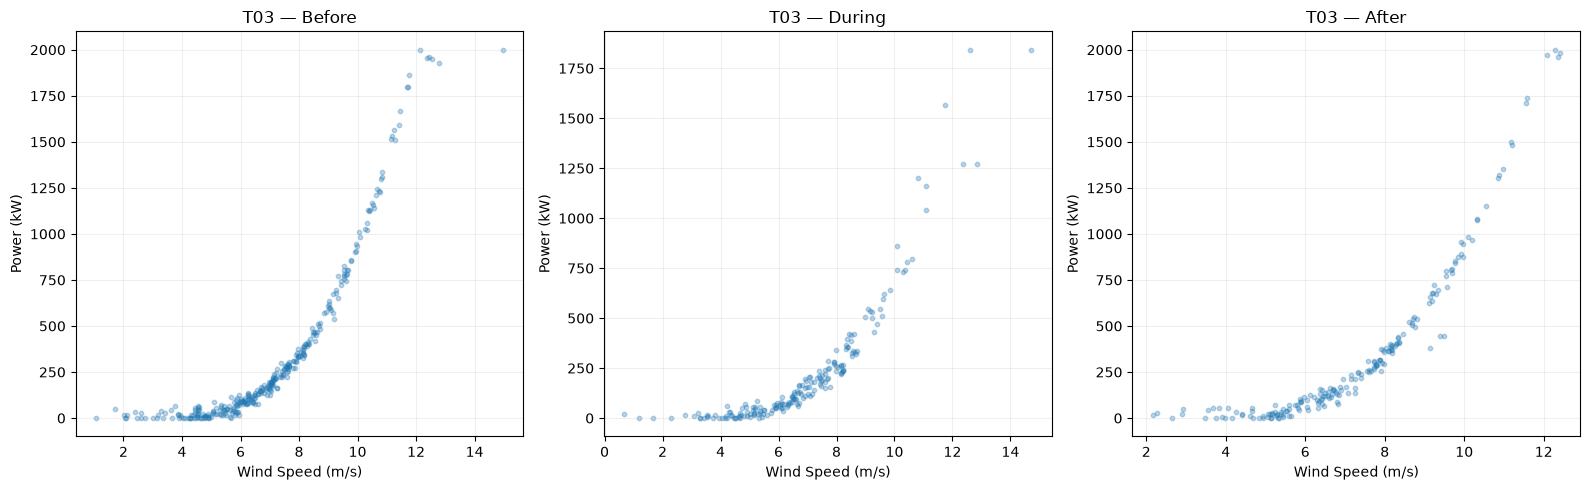

In [57]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

periods = [
    ("Before", "2026-04-20", "2026-05-04"),
    ("During", "2026-05-04", "2026-05-12"),
    ("After", "2026-05-12", "2026-05-20")
]

for ax, (name, start, end) in zip(axes, periods):

    temp = analysis_df[
        (analysis_df["turbine_id"] == candidate_turbine) &
        (analysis_df["timestamp"] >= start) &
        (analysis_df["timestamp"] < end)
    ]

    ax.scatter(
        temp["wind_speed_corrected"],
        temp["power_kw"],
        alpha=0.3,
        s=10
    )

    ax.set_title(f"T03 — {name}")
    ax.set_xlabel("Wind Speed (m/s)")
    ax.set_ylabel("Power (kW)")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [58]:
t03_analysis = power_analysis[
    power_analysis["turbine_id"] == "T03"
].copy()

t03_analysis["period"] = "Other"

t03_analysis.loc[
    (t03_analysis["timestamp"] >= "2026-05-04") &
    (t03_analysis["timestamp"] < "2026-05-12"),
    "period"
] = "During"

print(t03_analysis["period"].value_counts())

period
Other     1037
During      78
Name: count, dtype: int64


In [59]:
t03_during = t03_analysis[
    t03_analysis["period"] == "During"
].copy()

power_scaling_ratio = t03_during["power_ratio"].median()
power_correction_factor = 1 / power_scaling_ratio

print("Median power ratio:", power_scaling_ratio)
print("Correction factor:", power_correction_factor)

Median power ratio: 0.7586433910983084
Correction factor: 1.3181423732595539


In [60]:
t03_during["power_kw_corrected"] = (
    t03_during["power_kw"] * power_correction_factor
)

t03_during["corrected_ratio"] = (
    t03_during["power_kw_corrected"]
    / t03_during["expected_power_kw"]
)

In [61]:
print("BEFORE correction")
print(t03_during["power_ratio"].describe())

print("\nAFTER correction")
print(t03_during["corrected_ratio"].describe())

BEFORE correction
count    78.000000
mean      0.766496
std       0.116809
min       0.516534
25%       0.677774
50%       0.758643
75%       0.859315
max       1.018529
Name: power_ratio, dtype: float64

AFTER correction
count    78.000000
mean      1.010351
std       0.153971
min       0.680865
25%       0.893402
50%       1.000000
75%       1.132699
max       1.342566
Name: corrected_ratio, dtype: float64


In [62]:
print(
    "Maximum corrected power:",
    t03_during["power_kw_corrected"].max()
)

above_rated = (
    t03_during["power_kw_corrected"] > 2000
)

print(
    "Observations above 2000 kW:",
    above_rated.sum()
)

print(
    "Percentage above 2000 kW:",
    above_rated.mean() * 100
)

Maximum corrected power: 2428.94095120538
Observations above 2000 kW: 3
Percentage above 2000 kW: 3.8461538461538463


A multiplicative correction was investigated but rejected as a final cleaning operation because, although it restored the median actual/expected power ratio to 1.0, it produced corrected power values above the documented 2,000 kW rated output. The T03 observations during May 4–11 are therefore flagged rather than automatically corrected.

In [63]:
invalid_corrections = t03_during[
    t03_during["power_kw_corrected"] > 2000
][[
    "timestamp",
    "wind_speed_corrected",
    "power_kw",
    "expected_power_kw",
    "power_kw_corrected",
    "power_ratio",
    "corrected_ratio"
]]

invalid_corrections

,timestamp,wind_speed_corrected,power_kw,expected_power_kw,power_kw_corrected,power_ratio,corrected_ratio
7662,2026-05-04 11:00:00,14.72,1842.7,2000.000000,2428.940951,0.921350,1.214470
7667,2026-05-04 12:00:00,12.61,1839.3,2000.000000,2424.459267,0.919650,1.212230
7857,2026-05-06 02:00:00,11.74,1567.7,1831.625855,2066.451799,0.855906,1.128206


The T03 power anomaly is not suitable for correction using a single global scaling factor. Although multiplying the affected measurements by 1.318 restores the median actual/expected ratio to approximately 1.0, the correction produces values above the turbine's documented 2,000 kW rated output. The observations are therefore flagged rather than mechanically rescaled. The evidence is consistent with a temporary power-measurement or performance anomaly, but the available telemetry does not allow us to distinguish conclusively between sensor drift and actual turbine derating.

In [64]:
# Start from the original telemetry data
df_clean = df.copy()

# --------------------------------------------------
# 1. T05: use validated corrected wind speed
# --------------------------------------------------

df_clean["wind_speed_clean"] = df_clean["wind_speed"]

t05_anomaly = (
    (df_clean["turbine_id"] == "T05") &
    (df_clean["timestamp"] >= "2026-03-26") &
    (df_clean["timestamp"] <= "2026-04-04 23:00:00")
)

df_clean.loc[t05_anomaly, "wind_speed_clean"] = (
    df_clean.loc[t05_anomaly, "wind_speed"]
    / scaling_factor
)


# --------------------------------------------------
# 2. T03: flag anomaly, DO NOT correct power
# --------------------------------------------------

df_clean["power_anomaly_flag"] = 0

t03_anomaly = (
    (df_clean["turbine_id"] == "T03") &
    (df_clean["timestamp"] >= "2026-05-04") &
    (df_clean["timestamp"] < "2026-05-12")
)

df_clean.loc[t03_anomaly, "power_anomaly_flag"] = 1


# --------------------------------------------------
# 3. Keep original power unchanged
# --------------------------------------------------

df_clean["power_kw_clean"] = df_clean["power_kw"]


# --------------------------------------------------
# 4. Sort
# --------------------------------------------------

df_clean = df_clean.sort_values(
    ["timestamp", "turbine_id"]
).reset_index(drop=True)


print(df_clean.shape)
print(df_clean.head())

(10725, 8)
   timestamp turbine_id  wind_speed  power_kw  availability  wind_speed_clean  \
0 2026-03-01        T01        7.11     198.3           1.0              7.11   
1 2026-03-01        T02        5.42      25.6           1.0              5.42   
2 2026-03-01        T03        8.31     393.2           1.0              8.31   
3 2026-03-01        T04        4.82      11.3           1.0              4.82   
4 2026-03-01        T05        4.24      27.3           1.0              4.24   

   power_anomaly_flag  power_kw_clean  
0                   0           198.3  
1                   0            25.6  
2                   0           393.2  
3                   0            11.3  
4                   0            27.3  


In [65]:
df_clean.to_csv(
    "../data_pack/turbine_90_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
